# Audit du biais régional — ÉquiAlgo

**Question d'audit.** Les décisions d'octroi des bourses d'excellence, celles du comité historique et celles du modèle en production qui les imite, désavantagent-elles les candidat·es des régions éloignées à mérite égal ? Si oui, de combien, par quels canaux, et avec quelle métrique faut-il le mesurer ?

- **Grands centres** : Montréal, Capitale-Nationale.
- **Régions éloignées** : Bas-Saint-Laurent, Côte-Nord, Gaspésie–Îles-de-la-Madeleine.

Toutes les données sont synthétiques et l'institution est fictive. Ce carnet mesure ; la correction est dans `model_corrige.ipynb`. Il écrit `output/audit.json` et les figures `figures/audit_*.png`.

In [1]:
import json
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fairlearn.metrics import MetricFrame, demographic_parity_difference, selection_rate, true_positive_rate
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter
from scipy import stats
from scipy.stats.contingency import association
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

## Paramètres

Fixés avant toute analyse. Le modèle en production et l'étude des proxys reprennent les réglages du carnet de départ. Les valeurs annoncées par le brief servent de contrôle de reproduction, jamais de calcul.

In [2]:
GRAINE = 42
PART_TEST = 0.3
NB_ARBRES = 300
FEUILLE_MIN = 20
NB_ARBRES_PROXY = 100
FEUILLE_MIN_PROXY = 10
NB_PLIS = 5
NB_REECHANTILLONS = 500
NIVEAU_CONFIANCE = 0.95
SEUIL_SIGNIFICATION = 0.05
NB_TRANCHES_COTE_R = 10
TAUX_REFERENCE = 0.40
ENVELOPPE = (0.36, 0.44)
SANS_PENALITE = np.inf
ITERATIONS_MAX = 10_000
TOLERANCE = 1e-3
TOLERANCE_LOGIT = 0.1
BA_HASARD = 0.5
DECIMALES_EXPORT = 6
UNITE_BASE = 10

DOSSIER_DONNEES = Path("data")
DOSSIER_FIGURES = Path("figures")
FICHIER_AUDIT = Path("output") / "audit.json"

IDENTIFIANT = "id_candidat"
CIBLE = "decision_octroi"
COTE_R = "cote_r_equivalent"
PROGRAMME = "programme_etudes"
REGION = "region_administrative"
CODE_POSTAL = "code_postal_3"
REVENU = "revenu_familial_estime"
HEURES = "heures_travail_semaine"
DISTANCE = "distance_domicile_campus_km"
PREMIERE_GENERATION = "premiere_generation_universitaire"
GROUPE = "groupe"
INDICATRICE_ELOIGNEE = "region_eloignee"
CONSTANTE = "constante"

COLONNES_CANDIDATS = [
    IDENTIFIANT,
    COTE_R,
    PROGRAMME,
    REGION,
    CODE_POSTAL,
    REVENU,
    HEURES,
    DISTANCE,
    PREMIERE_GENERATION,
]
COLONNES_DEMANDES = [*COLONNES_CANDIDATS, CIBLE]
CRITERES_NUMERIQUES = [COTE_R, REVENU, HEURES]
CATEGORIELLES = [PROGRAMME, REGION, CODE_POSTAL]
VARIABLES_PROXY = [COTE_R, PROGRAMME, CODE_POSTAL, REVENU, HEURES, DISTANCE, PREMIERE_GENERATION]
COLONNES_TEXTE = [PROGRAMME, CODE_POSTAL]
MOTIF_IDENTIFIANT = r"C\d{6}"
BORNES_COTE_R = (15, 40)
NB_PROGRAMMES = 5

GRANDS_CENTRES = ["Montreal", "Capitale-Nationale"]
REGIONS_ELOIGNEES = ["Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"]
REGIONS = [*GRANDS_CENTRES, *REGIONS_ELOIGNEES]
REGION_REFERENCE = "Montreal"
CENTRE = "Centre"
ELOIGNEE = "Eloignee"

NOMS_REGIONS = {
    "Montreal": "Montréal",
    "Capitale-Nationale": "Capitale-Nationale",
    "Bas-Saint-Laurent": "Bas-Saint-Laurent",
    "Cote-Nord": "Côte-Nord",
    "Gaspesie-Iles-de-la-Madeleine": "Gaspésie–Îles-de-la-Madeleine",
}
NOMS_GROUPES = {CENTRE: "Grands centres", ELOIGNEE: "Régions éloignées"}
LIBELLES = {
    COTE_R: "Cote R",
    PROGRAMME: "Programme d'études",
    REGION: "Région administrative",
    CODE_POSTAL: "Code postal (3 caractères)",
    REVENU: "Revenu familial",
    HEURES: "Heures travaillées",
    DISTANCE: "Distance domicile–campus",
    PREMIERE_GENERATION: "Première génération",
    INDICATRICE_ELOIGNEE: "Région éloignée",
    CONSTANTE: "Constante",
}

VALEURS_BRIEF = {
    "taux d'octroi des grands centres": (0.484, 3),
    "taux d'octroi des régions éloignées": (0.273, 3),
    "exactitude du modèle en production": (0.88, 2),
    "Toutes les colonnes": (0.188, 3),
    "Sans région administrative": (0.181, 3),
    "Sans région ni code postal": (0.173, 3),
}
ECART_EGALITE_CHANCES_BRIEF = 0.270

COULEURS = {CENTRE: "#0072BA", ELOIGNEE: "#F2682A"}
BLEU_IVADO = "#0072BA"
ENCRE = "#232323"
GRILLE = "#E1E1E1"
TAILLE_POLICE = 11
TAILLE_TITRE = 13
TAILLE_FIGURE = (8, 4.5)
TAILLE_FIGURE_PROXYS = (8, 6)
EPAISSEUR_LIGNE = 2
EPAISSEUR_REPERE = 1
TAILLE_MARQUEUR = 6
TAILLE_EMBOUT = 3
RESOLUTION = 150
ESPACE_FINE = " "
ESPACE_INSECABLE = " "
MOINS = "−"

Fonctions communes : nombres au format français, tableaux, contrôles bloquants, figures, et sélection des meilleurs dossiers à un taux donné (départage déterministe par empreinte de l'identifiant, comme dans le carnet de départ).

In [3]:
plt.rcParams.update(
    {
        "font.size": TAILLE_POLICE,
        "axes.titlesize": TAILLE_TITRE,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE,
        "axes.edgecolor": ENCRE,
        "xtick.color": ENCRE,
        "ytick.color": ENCRE,
    }
)
Z_CRITIQUE = stats.norm.ppf((1 + NIVEAU_CONFIANCE) / 2)
QUANTILES_IC = [(1 - NIVEAU_CONFIANCE) / 2, (1 + NIVEAU_CONFIANCE) / 2]


def nombre(valeur, decimales=0):
    texte = f"{round(float(valeur), decimales) + 0.0:,.{decimales}f}"
    return texte.replace(",", ESPACE_FINE).replace(".", ",").replace("-", MOINS)


def pourcent(valeur, decimales=1):
    return f"{nombre(100 * valeur, decimales)}{ESPACE_INSECABLE}%"


def points(valeur, decimales=1):
    return f"{nombre(100 * valeur, decimales)}{ESPACE_INSECABLE}points"


def intervalle_texte(bas, haut, decimales=3):
    return f"[{nombre(bas, decimales)} ; {nombre(haut, decimales)}]"


def dire(texte):
    display(Markdown(texte))


def formater_cellule(valeur, decimales):
    if isinstance(valeur, bool | np.bool_ | str):
        return valeur
    return nombre(valeur, 0 if isinstance(valeur, int | np.integer) else decimales)


def afficher(tableau, formats=None, decimales=3):
    style = tableau.style.format(lambda valeur: formater_cellule(valeur, decimales), na_rep="—")
    if formats:
        style = style.format(formats, subset=list(formats), na_rep="—")
    display(style)


def verifier(controles):
    echecs = [nom for nom, reussi in controles.items() if not reussi]
    assert not echecs, f"Contrôles en échec : {echecs}"


def conforme_au_brief(valeurs):
    return {
        nom: abs(valeur - VALEURS_BRIEF[nom][0]) <= UNITE_BASE ** -VALEURS_BRIEF[nom][1]
        for nom, valeur in valeurs.items()
    }


def styliser(axe, titre, legende_x, legende_y, grille="y"):
    axe.set_title(titre, loc="left")
    axe.set_xlabel(legende_x)
    axe.set_ylabel(legende_y)
    axe.spines[["top", "right"]].set_visible(False)
    axe.grid(axis=grille, color=GRILLE)
    axe.set_axisbelow(True)


def enregistrer(figure, nom):
    DOSSIER_FIGURES.mkdir(exist_ok=True)
    figure.savefig(DOSSIER_FIGURES / nom, dpi=RESOLUTION, bbox_inches="tight")
    plt.show()


def groupe_region(tableau):
    return np.where(tableau[REGION].isin(REGIONS_ELOIGNEES), ELOIGNEE, CENTRE)


def selection_meilleurs(scores, taux, identifiants):
    nb_retenus = round(taux * len(scores))
    empreintes = pd.util.hash_pandas_object(identifiants, index=False).to_numpy()
    ordre = np.lexsort((empreintes, -np.asarray(scores)))
    decisions = np.zeros(len(scores), dtype=int)
    decisions[ordre[:nb_retenus]] = 1
    return decisions

## 1. Données et validation

Avant tout calcul, le schéma des deux fichiers est vérifié : colonnes, valeurs manquantes, format et unicité des identifiants, régions, bornes de la cote R, variables binaires. Les identifiants des deux fichiers doivent être disjoints. Un échec arrête le carnet.

In [4]:
demandes = pd.read_csv(DOSSIER_DONNEES / "donnees_demandes.csv")
candidats = pd.read_csv(DOSSIER_DONNEES / "candidats_evaluation.csv")


def controles_schema(tableau, colonnes):
    return {
        "colonnes attendues": list(tableau.columns) == colonnes,
        "aucune valeur manquante": bool(tableau.notna().all().all()),
        "identifiants uniques": bool(tableau[IDENTIFIANT].is_unique),
        "format des identifiants": bool(tableau[IDENTIFIANT].str.fullmatch(MOTIF_IDENTIFIANT).all()),
        "régions attendues": set(tableau[REGION]) == set(REGIONS),
        "cote R dans les bornes": bool(tableau[COTE_R].between(*BORNES_COTE_R).all()),
        "programmes attendus": tableau[PROGRAMME].nunique() == NB_PROGRAMMES,
        "première génération binaire": set(tableau[PREMIERE_GENERATION]) <= {0, 1},
    }


schema_demandes = controles_schema(demandes, COLONNES_DEMANDES)
schema_candidats = controles_schema(candidats, COLONNES_CANDIDATS)
controles_croises = {
    "décision binaire (historique)": set(demandes[CIBLE]) <= {0, 1},
    "identifiants disjoints entre fichiers": set(demandes[IDENTIFIANT]).isdisjoint(candidats[IDENTIFIANT]),
}
for controles in (schema_demandes, schema_candidats, controles_croises):
    verifier(controles)

etat = pd.DataFrame({"Historique": schema_demandes, "Évaluation": schema_candidats})
display(etat.map({True: "réussi", False: "échec"}.get))
dire(
    f"{nombre(len(demandes))} dossiers historiques avec décision du comité, "
    f"{nombre(len(candidats))} dossiers à évaluer sans étiquette. "
    f"Tous les contrôles passent, y compris : {', '.join(controles_croises)}."
)

,Historique,Évaluation
colonnes attendues,réussi,réussi
aucune valeur manquante,réussi,réussi
identifiants uniques,réussi,réussi
format des identifiants,réussi,réussi
régions attendues,réussi,réussi
cote R dans les bornes,réussi,réussi
programmes attendus,réussi,réussi
première génération binaire,réussi,réussi


10 000 dossiers historiques avec décision du comité, 4 000 dossiers à évaluer sans étiquette. Tous les contrôles passent, y compris : décision binaire (historique), identifiants disjoints entre fichiers.

Les dossiers à évaluer doivent venir de la même population que l'historique, sinon ce qui est mesuré sur l'historique ne s'appliquerait pas à eux. Test de Kolmogorov-Smirnov pour les variables numériques, test du khi-deux d'homogénéité pour les catégories, avec correction de Bonferroni pour le nombre de tests.

In [5]:
def test_numerique(colonne):
    resultat = stats.ks_2samp(demandes[colonne], candidats[colonne])
    return {
        "Variable": LIBELLES[colonne],
        "Test": "Kolmogorov-Smirnov",
        "Statistique": resultat.statistic,
        "Valeur p": resultat.pvalue,
    }


def test_categoriel(colonne):
    valeurs = pd.concat([demandes[colonne], candidats[colonne]], ignore_index=True)
    source = np.repeat(["historique", "evaluation"], [len(demandes), len(candidats)])
    resultat = stats.chi2_contingency(pd.crosstab(valeurs, source))
    return {
        "Variable": LIBELLES[colonne],
        "Test": "khi-deux",
        "Statistique": resultat.statistic,
        "Valeur p": resultat.pvalue,
    }


tests_distribution = pd.DataFrame(
    [test_numerique(colonne) for colonne in [*CRITERES_NUMERIQUES, DISTANCE]]
    + [test_categoriel(colonne) for colonne in [*CATEGORIELLES, PREMIERE_GENERATION]]
).set_index("Variable")
afficher(tests_distribution)

p_minimale = tests_distribution["Valeur p"].min()
seuil_corrige = SEUIL_SIGNIFICATION / len(tests_distribution)
part_eloignee = {
    nom: np.mean(groupe_region(t) == ELOIGNEE) for nom, t in (("hist", demandes), ("eval", candidats))
}
verdict_distribution = (
    "aucune différence n'est significative"
    if p_minimale > seuil_corrige
    else "au moins une différence est significative"
)
dire(
    f"La plus petite valeur p ({tests_distribution['Valeur p'].idxmin()}) vaut {nombre(p_minimale, 3)} ; "
    f"avec {len(tests_distribution)} tests, le seuil corrigé est {nombre(seuil_corrige, 4)} : "
    f"{verdict_distribution}. "
    f"Les régions éloignées représentent {pourcent(part_eloignee['hist'])} de l'historique et "
    f"{pourcent(part_eloignee['eval'])} des dossiers à évaluer ; cote R moyenne "
    f"{nombre(demandes[COTE_R].mean(), 2)} contre {nombre(candidats[COTE_R].mean(), 2)}."
)

,Test,Statistique,Valeur p
Variable,,,
Cote R,Kolmogorov-Smirnov,"0,015","0,533"
Revenu familial,Kolmogorov-Smirnov,"0,017","0,346"
Heures travaillées,Kolmogorov-Smirnov,"0,008","0,997"
Distance domicile–campus,Kolmogorov-Smirnov,"0,014","0,585"
Programme d'études,khi-deux,"10,517","0,033"
Région administrative,khi-deux,"2,864","0,581"
Code postal (3 caractères),khi-deux,"17,701","0,408"
Première génération,khi-deux,"0,397","0,529"


La plus petite valeur p (Programme d'études) vaut 0,033 ; avec 8 tests, le seuil corrigé est 0,0063 : aucune différence n'est significative. Les régions éloignées représentent 40,0 % de l'historique et 40,7 % des dossiers à évaluer ; cote R moyenne 27,72 contre 27,80.

## 2. Disparités observées

Taux d'octroi du comité et cote R moyenne, par région puis par groupe, sur les décisions historiques.

In [6]:
demandes[GROUPE] = groupe_region(demandes)
candidats[GROUPE] = groupe_region(candidats)
COLONNES_RESUME = {"dossiers": "Dossiers", "taux_octroi": "Taux d'octroi", "cote_r_moyenne": "Cote R moyenne"}


def resume_octroi(tableau, cle):
    return tableau.groupby(cle).agg(
        dossiers=(CIBLE, "size"), taux_octroi=(CIBLE, "mean"), cote_r_moyenne=(COTE_R, "mean")
    )


par_region = resume_octroi(demandes, REGION).reindex(REGIONS)
par_groupe = resume_octroi(demandes, GROUPE)
vue_regions = pd.concat([par_region.rename(index=NOMS_REGIONS), par_groupe.rename(index=NOMS_GROUPES)])
afficher(vue_regions.rename(columns=COLONNES_RESUME), {"Taux d'octroi": pourcent}, decimales=2)

taux_centres, taux_eloignees = par_groupe.loc[[CENTRE, ELOIGNEE], "taux_octroi"]
cote_centres, cote_eloignees = par_groupe.loc[[CENTRE, ELOIGNEE], "cote_r_moyenne"]
ecart_octroi = taux_centres - taux_eloignees
verifier(
    conforme_au_brief(
        {
            "taux d'octroi des grands centres": taux_centres,
            "taux d'octroi des régions éloignées": taux_eloignees,
        }
    )
)
taux_par_bloc = {
    nom: par_region.loc[liste, "taux_octroi"]
    for nom, liste in (("c", GRANDS_CENTRES), ("e", REGIONS_ELOIGNEES))
}
dire(
    f"Le comité a accordé une bourse à **{pourcent(taux_centres)}** des candidat·es des grands centres et à "
    f"**{pourcent(taux_eloignees)}** de celles et ceux des régions éloignées : un écart de "
    f"**{points(ecart_octroi)}**. "
    f"La cote R moyenne est de {nombre(cote_centres, 1)} contre {nombre(cote_eloignees, 1)}. Les chiffres du "
    "brief "
    f"sont reproduits. Les grands centres ont des taux voisins ({pourcent(taux_par_bloc['c'].min())} à "
    f"{pourcent(taux_par_bloc['c'].max())}), les régions éloignées aussi "
    f"({pourcent(taux_par_bloc['e'].min())} à "
    f"{pourcent(taux_par_bloc['e'].max())}) : le clivage est entre les deux groupes, pas entre régions."
)

,Dossiers,Taux d'octroi,Cote R moyenne
Montréal,4 001,"48,3 %","27,99"
Capitale-Nationale,1 999,"48,4 %","27,98"
Bas-Saint-Laurent,1 293,"26,9 %","27,30"
Côte-Nord,1 178,"26,3 %","27,33"
Gaspésie–Îles-de-la-Madeleine,1 529,"28,4 %","27,35"
Grands centres,6 000,"48,4 %","27,99"
Régions éloignées,4 000,"27,3 %","27,33"


Le comité a accordé une bourse à **48,4 %** des candidat·es des grands centres et à **27,3 %** de celles et ceux des régions éloignées : un écart de **21,1 points**. La cote R moyenne est de 28,0 contre 27,3. Les chiffres du brief sont reproduits. Les grands centres ont des taux voisins (48,3 % à 48,4 %), les régions éloignées aussi (26,3 % à 28,4 %) : le clivage est entre les deux groupes, pas entre régions.

Même question à cote R comparable : les dossiers sont répartis en déciles de cote R et, dans chaque décile, les taux d'octroi des deux groupes sont comparés. Si la cote R expliquait l'écart, les deux courbes se superposeraient.

,"Dossiers, grands centres","Dossiers, régions éloignées","Taux, grands centres","Taux, régions éloignées",Écart (points)
Décile de cote R,,,,,
"16,8 – 23,9",496,505,"0,0 %","0,0 %","0,0"
"23,9 – 25,2",571,428,"1,2 %","0,2 %","1,0"
"25,2 – 26,2",563,455,"6,2 %","1,5 %","4,7"
"26,2 – 26,9",562,421,"15,7 %","4,0 %","11,6"
"26,9 – 27,7",604,400,"29,3 %","9,0 %","20,3"
"27,7 – 28,5",611,388,"45,7 %","16,8 %","28,9"
"28,5 – 29,3",623,376,"69,7 %","37,8 %","31,9"
"29,3 – 30,2",605,397,"89,8 %","62,5 %","27,3"
"30,2 – 31,6",662,334,"96,2 %","86,5 %","9,7"


À cote R comparable, l'écart moyen pondéré reste de **13,8 points** (contre 21,1 points au total) ; il culmine à 31,9 points dans le décile 28,5 – 29,3. Même cote R, chance différente.

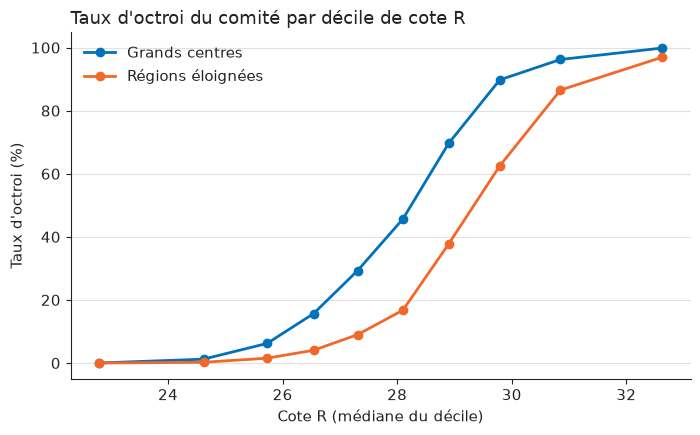

In [7]:
tranches = pd.qcut(demandes[COTE_R], NB_TRANCHES_COTE_R)
par_tranche = demandes.groupby([tranches, GROUPE], observed=True)[CIBLE].agg(["mean", "size"]).unstack(GROUPE)
ecarts_tranche = par_tranche["mean"][CENTRE] - par_tranche["mean"][ELOIGNEE]
ecart_moyen_tranche = np.average(ecarts_tranche, weights=par_tranche["size"].sum(axis=1))
etiquettes_tranches = [f"{nombre(t.left, 1)} – {nombre(t.right, 1)}" for t in par_tranche.index]

vue_tranches = pd.DataFrame(
    {
        "Dossiers, grands centres": par_tranche["size"][CENTRE].to_numpy(),
        "Dossiers, régions éloignées": par_tranche["size"][ELOIGNEE].to_numpy(),
        "Taux, grands centres": par_tranche["mean"][CENTRE].to_numpy(),
        "Taux, régions éloignées": par_tranche["mean"][ELOIGNEE].to_numpy(),
        "Écart (points)": 100 * ecarts_tranche.to_numpy(),
    },
    index=pd.Index(etiquettes_tranches, name="Décile de cote R"),
)
afficher(vue_tranches, {"Taux, grands centres": pourcent, "Taux, régions éloignées": pourcent}, decimales=1)

position_max = int(np.argmax(ecarts_tranche.to_numpy()))
dire(
    f"À cote R comparable, l'écart moyen pondéré reste de **{points(ecart_moyen_tranche)}** "
    f"(contre {points(ecart_octroi)} au total) ; il culmine à {points(ecarts_tranche.iloc[position_max])} "
    f"dans le décile {etiquettes_tranches[position_max]}. Même cote R, chance différente."
)

medianes = demandes.groupby(tranches, observed=True)[COTE_R].median()
figure, axe = plt.subplots(figsize=TAILLE_FIGURE)
for groupe in (CENTRE, ELOIGNEE):
    axe.plot(
        medianes,
        100 * par_tranche["mean"][groupe],
        marker="o",
        markersize=TAILLE_MARQUEUR,
        linewidth=EPAISSEUR_LIGNE,
        color=COULEURS[groupe],
        label=NOMS_GROUPES[groupe],
    )
styliser(
    axe, "Taux d'octroi du comité par décile de cote R", "Cote R (médiane du décile)", "Taux d'octroi (%)"
)
axe.legend(frameon=False)
enregistrer(figure, "audit_taux_par_cote_r.png")

## 3. Décomposer l'écart

**Méthode.** On estime la règle appliquée aux grands centres : une régression logistique des décisions sur les critères du dossier (cote R, revenu familial, heures travaillées, programme, première génération), ajustée sur leurs seuls dossiers. Appliquée aux candidat·es des régions éloignées, elle donne le taux qu'ils auraient obtenu s'ils avaient été jugés comme les grands centres.

- **Écart expliqué** = taux des grands centres − taux contrefactuel des régions éloignées : la part due aux différences de profil.
- **Écart inexpliqué** = taux contrefactuel − taux réel des régions éloignées : la part qu'aucun critère du dossier n'explique.

La part expliquée est répartie entre critères au prorata de la contribution de chaque critère à l'écart moyen du score logit (coefficient × différence des moyennes). La distance et le code postal ne sont pas des critères du dossier : ils sont étudiés aux sections 4 et 7.

Les critères numériques sont standardisés sur l'historique ; le programme entre en indicatrices, le premier par ordre alphabétique servant de référence. Cette mise en forme sert aux sections suivantes.

In [8]:
moyennes = demandes[[*CRITERES_NUMERIQUES, DISTANCE]].mean()
ecarts_types = demandes[[*CRITERES_NUMERIQUES, DISTANCE]].std()
programmes = sorted(demandes[PROGRAMME].unique())
colonnes_programme = [f"{PROGRAMME}_{programme}" for programme in programmes[1:]]
critere_de_colonne = dict.fromkeys(colonnes_programme, LIBELLES[PROGRAMME]) | {
    colonne: LIBELLES[colonne] for colonne in [*CRITERES_NUMERIQUES, PREMIERE_GENERATION]
}
ORDRE_CRITERES = [LIBELLES[colonne] for colonne in [COTE_R, REVENU, HEURES, PROGRAMME, PREMIERE_GENERATION]]
libelles_colonnes = LIBELLES | {
    colonne: f"{LIBELLES[PROGRAMME]} : {programme}"
    for colonne, programme in zip(colonnes_programme, programmes[1:], strict=True)
}


def standardiser(tableau, colonnes):
    return (tableau[colonnes] - moyennes[colonnes]) / ecarts_types[colonnes]


def criteres(tableau, numeriques=CRITERES_NUMERIQUES):
    programme = pd.get_dummies(tableau[PROGRAMME], prefix=PROGRAMME, dtype=float)
    return pd.concat(
        [
            standardiser(tableau, numeriques),
            programme.reindex(columns=colonnes_programme, fill_value=0.0),
            tableau[[PREMIERE_GENERATION]].astype(float),
        ],
        axis=1,
    )


def avec_eloignee(tableau, x):
    return x.assign(**{INDICATRICE_ELOIGNEE: (tableau[GROUPE] == ELOIGNEE).astype(float).to_numpy()})


def avec_regions(tableau, x):
    regions = pd.get_dummies(tableau[REGION], dtype=float)
    autres = [region for region in REGIONS if region != REGION_REFERENCE]
    return pd.concat([x, regions.reindex(columns=autres, fill_value=0.0)], axis=1)


def ajuster_logit(x, y):
    return LogisticRegression(C=SANS_PENALITE, max_iter=ITERATIONS_MAX).fit(x, y)


def probabilite_moyenne(modele, x):
    return modele.predict_proba(x)[:, 1].mean()


y_demandes = demandes[CIBLE]
x_criteres = criteres(demandes)
masque_eloignee = (demandes[GROUPE] == ELOIGNEE).to_numpy()
regle_centres = ajuster_logit(x_criteres[~masque_eloignee], y_demandes[~masque_eloignee])
taux_contrefactuel = probabilite_moyenne(regle_centres, x_criteres[masque_eloignee])
verifier(
    {
        "la règle des grands centres reproduit leur taux": np.isclose(
            probabilite_moyenne(regle_centres, x_criteres[~masque_eloignee]), taux_centres, atol=TOLERANCE
        )
    }
)
ecart_explique = taux_centres - taux_contrefactuel
ecart_inexplique = taux_contrefactuel - taux_eloignees

difference_moyennes = x_criteres[~masque_eloignee].mean() - x_criteres[masque_eloignee].mean()
contributions = pd.Series(regle_centres.coef_[0], index=x_criteres.columns) * difference_moyennes
parts_criteres = (ecart_explique * contributions / contributions.sum()).groupby(critere_de_colonne).sum()
decomposition = pd.concat(
    [
        parts_criteres.reindex(ORDRE_CRITERES),
        pd.Series(
            {
                "Total expliqué par le profil": ecart_explique,
                "Inexpliqué": ecart_inexplique,
                "Écart observé": ecart_octroi,
            }
        ),
    ]
)
vue_decomposition = pd.DataFrame(
    {"Écart (points)": 100 * decomposition, "Part de l'écart": decomposition / ecart_octroi}
)
afficher(vue_decomposition, {"Part de l'écart": pourcent}, decimales=1)

part_cote_r = parts_criteres[LIBELLES[COTE_R]] / ecart_octroi
part_inexpliquee = ecart_inexplique / ecart_octroi
part_autres_criteres = 1 - part_cote_r - part_inexpliquee
verifier(
    {
        "heures plus nombreuses en région éloignée": difference_moyennes[HEURES] < 0,
        "heures valorisées par le comité": regle_centres.coef_[0][x_criteres.columns.get_loc(HEURES)] > 0,
    }
)
dire(
    f"Jugés selon la règle des grands centres, les candidat·es des régions éloignées obtiendraient "
    f"**{pourcent(taux_contrefactuel)}** au lieu de {pourcent(taux_eloignees)}. Sur les "
    f"{points(ecart_octroi)} "
    f"d'écart, {points(ecart_explique)} ({pourcent(ecart_explique / ecart_octroi, 0)}) tiennent aux "
    "différences de "
    f"profil et **{points(ecart_inexplique)} ({pourcent(part_inexpliquee, 0)}) restent inexpliqués**.\n\n"
    f"La cote R explique à elle seule {points(parts_criteres[LIBELLES[COTE_R]])} "
    f"({pourcent(part_cote_r, 0)} de l'écart) et le revenu familial "
    f"{points(parts_criteres[LIBELLES[REVENU]])}. "
    f"Les heures travaillées jouent en sens inverse ({points(parts_criteres[LIBELLES[HEURES]])}) : les "
    "candidat·es "
    "éloigné·es travaillent davantage, ce que le comité valorise. Ensemble, les critères autres que la cote "
    "R "
    f"pèsent {pourcent(part_autres_criteres, 0)} de l'écart ; une part négative le réduit."
)

,Écart (points),Part de l'écart
Cote R,"7,6","36,1 %"
Revenu familial,"3,6","16,9 %"
Heures travaillées,"−7,2","−34,3 %"
Programme d'études,"0,0","0,1 %"
Première génération,"0,0","0,0 %"
Total expliqué par le profil,"4,0","18,8 %"
Inexpliqué,"17,1","81,2 %"
Écart observé,"21,1","100,0 %"


Jugés selon la règle des grands centres, les candidat·es des régions éloignées obtiendraient **44,4 %** au lieu de 27,3 %. Sur les 21,1 points d'écart, 4,0 points (19 %) tiennent aux différences de profil et **17,1 points (81 %) restent inexpliqués**.

La cote R explique à elle seule 7,6 points (36 % de l'écart) et le revenu familial 3,6 points. Les heures travaillées jouent en sens inverse (−7,2 points) : les candidat·es éloigné·es travaillent davantage, ce que le comité valorise. Ensemble, les critères autres que la cote R pèsent −17 % de l'écart ; une part négative le réduit.

## 4. La règle du comité

Régression logistique sans pénalisation sur toutes les décisions historiques : critères du dossier et un effet fixe par région, Montréal en référence. Chaque coefficient régional mesure ce que coûte la région à dossier égal, sur l'échelle logit.

In [9]:
def erreurs_types(modele, x):
    plan = np.column_stack([np.ones(len(x)), x.to_numpy()])
    probabilites = modele.predict_proba(x)[:, 1]
    information = plan.T @ (plan * (probabilites * (1 - probabilites))[:, None])
    return pd.Series(np.sqrt(np.diag(np.linalg.inv(information)))[1:], index=x.columns)


def tableau_coefficients(modele, x):
    coefficients = pd.Series(modele.coef_[0], index=x.columns)
    erreurs = erreurs_types(modele, x)
    return pd.DataFrame(
        {
            "Coefficient": coefficients,
            "Erreur type": erreurs,
            "IC bas": coefficients - Z_CRITIQUE * erreurs,
            "IC haut": coefficients + Z_CRITIQUE * erreurs,
        }
    )


def log_vraisemblance(modele, x, y):
    return -log_loss(y, modele.predict_proba(x)[:, 1], normalize=False)


def rapport_vraisemblance(complet, reduit, y):
    statistique = 2 * (log_vraisemblance(*complet, y) - log_vraisemblance(*reduit, y))
    degres = complet[1].shape[1] - reduit[1].shape[1]
    return statistique, degres, stats.chi2.sf(statistique, degres)


x_regions = avec_regions(demandes, x_criteres)
modele_regions = ajuster_logit(x_regions, y_demandes)
coefficients_regions = tableau_coefficients(modele_regions, x_regions).reindex(REGIONS)
coefficients_regions.loc[REGION_REFERENCE, "Coefficient"] = 0.0
afficher(
    coefficients_regions.rename(index=NOMS_REGIONS).rename_axis("Région (référence : Montréal)"), decimales=3
)
penalites_eloignees = coefficients_regions.loc[REGIONS_ELOIGNEES, "Coefficient"]
dire(
    f"Les régions éloignées subissent une pénalité de {nombre(penalites_eloignees.max(), 2)} à "
    f"{nombre(penalites_eloignees.min(), 2)} sur l'échelle logit ; la Capitale-Nationale, "
    f"{nombre(coefficients_regions.loc['Capitale-Nationale', 'Coefficient'], 2)}, ne se distingue pas de "
    "Montréal. "
    f"Intervalles de confiance à {pourcent(NIVEAU_CONFIANCE, 0)}."
)

,Coefficient,Erreur type,IC bas,IC haut
Région (référence : Montréal),,,,
Montréal,"0,000",—,—,—
Capitale-Nationale,"−0,054","0,093","−0,236","0,128"
Bas-Saint-Laurent,"−2,045","0,133","−2,306","−1,785"
Côte-Nord,"−2,054","0,137","−2,322","−1,786"
Gaspésie–Îles-de-la-Madeleine,"−1,938","0,125","−2,183","−1,694"


Les régions éloignées subissent une pénalité de −1,94 à −2,05 sur l'échelle logit ; la Capitale-Nationale, −0,05, ne se distingue pas de Montréal. Intervalles de confiance à 95 %.

Si les régions éloignées subissent toutes la même pénalité et la Capitale-Nationale aucune, un seul terme binaire « région éloignée » suffit. Test du rapport de vraisemblance entre les deux spécifications, puis comparaison des décisions qu'elles produisent.

In [10]:
x_binaire = avec_eloignee(demandes, x_criteres)
modele_comite = ajuster_logit(x_binaire, y_demandes)
coefficients_comite = tableau_coefficients(modele_comite, x_binaire)
statistique_rv, degres_rv, p_regions = rapport_vraisemblance(
    (modele_regions, x_regions), (modele_comite, x_binaire), y_demandes
)
accord_historique = np.mean(modele_regions.predict(x_regions) == modele_comite.predict(x_binaire))

x_candidats_criteres = criteres(candidats)


def selection_sans_penalite(modele, x):
    poids = pd.Series(modele.coef_[0], index=modele.feature_names_in_)[x.columns]
    return selection_meilleurs(x.to_numpy() @ poids.to_numpy(), TAUX_REFERENCE, candidats[IDENTIFIANT])


accord_selection = np.mean(
    selection_sans_penalite(modele_regions, x_candidats_criteres)
    == selection_sans_penalite(modele_comite, x_candidats_criteres)
)
afficher(coefficients_comite.rename(index=libelles_colonnes).rename_axis("Règle du comité, terme binaire"))
verdict_regions = "ne rejette pas" if p_regions > SEUIL_SIGNIFICATION else "rejette"
dire(
    f"Le test du rapport de vraisemblance {verdict_regions} le terme binaire (statistique "
    f"{nombre(statistique_rv, 2)}, {degres_rv} degrés de liberté, p = {nombre(p_regions, 3)}). Les deux "
    f"spécifications prédisent la même décision pour **{pourcent(accord_historique, 2)}** des dossiers "
    "historiques "
    "et, une fois la pénalité retirée, retiennent les mêmes candidat·es pour "
    f"{pourcent(accord_selection, 2)} des "
    f"dossiers à évaluer au taux de {pourcent(TAUX_REFERENCE, 0)}. La pénalité binaire vaut "
    f"**{nombre(coefficients_comite.loc[INDICATRICE_ELOIGNEE, 'Coefficient'], 2)}** "
    f"(IC {intervalle_texte(*coefficients_comite.loc[INDICATRICE_ELOIGNEE, ['IC bas', 'IC haut']], 2)})."
)

,Coefficient,Erreur type,IC bas,IC haut
"Règle du comité, terme binaire",,,,
Cote R,"4,132","0,090","3,955","4,308"
Revenu familial,"0,755","0,040","0,676","0,834"
Heures travaillées,"0,758","0,044","0,672","0,844"
Programme d'études : Genie,"0,044","0,112","−0,175","0,263"
Programme d'études : Sante,"0,055","0,120","−0,180","0,290"
Programme d'études : Sciences,"0,018","0,114","−0,206","0,242"
Programme d'études : Sciences sociales,"−0,010","0,115","−0,235","0,215"
Première génération,"−0,049","0,076","−0,198","0,101"
Région éloignée,"−1,995","0,097","−2,185","−1,806"


Le test du rapport de vraisemblance ne rejette pas le terme binaire (statistique 1,23, 3 degrés de liberté, p = 0,747). Les deux spécifications prédisent la même décision pour **99,70 %** des dossiers historiques et, une fois la pénalité retirée, retiennent les mêmes candidat·es pour 100,00 % des dossiers à évaluer au taux de 40 %. La pénalité binaire vaut **−2,00** (IC [−2,19 ; −1,81]).

Le comité applique-t-il les mêmes critères dans les deux groupes ? La même régression est ajustée séparément dans chaque groupe, puis un test du rapport de vraisemblance compare le modèle commun (une seule pente par critère, plus la pénalité) au modèle où chaque pente diffère selon le groupe.

In [11]:
pentes = pd.DataFrame(
    {
        NOMS_GROUPES[groupe]: ajuster_logit(x_criteres[masque], y_demandes[masque]).coef_[0]
        for groupe, masque in ((CENTRE, ~masque_eloignee), (ELOIGNEE, masque_eloignee))
    },
    index=x_criteres.columns,
)
pentes["Modèle commun"] = coefficients_comite.loc[x_criteres.columns, "Coefficient"]
afficher(pentes.rename(index=libelles_colonnes).rename_axis("Coefficient par critère"))

x_interactions = pd.concat(
    [x_binaire, x_criteres.mul(x_binaire[INDICATRICE_ELOIGNEE], axis=0).add_suffix("_x_eloignee")], axis=1
)
modele_interactions = ajuster_logit(x_interactions, y_demandes)
statistique_pentes, degres_pentes, p_pentes = rapport_vraisemblance(
    (modele_interactions, x_interactions), (modele_comite, x_binaire), y_demandes
)
verdict_pentes = "ne diffèrent pas significativement" if p_pentes > SEUIL_SIGNIFICATION else "diffèrent"
dire(
    f"Les pentes {verdict_pentes} entre groupes (statistique {nombre(statistique_pentes, 2)}, "
    f"{degres_pentes} "
    f"degrés de liberté, p = {nombre(p_pentes, 3)}) : le comité applique les mêmes critères partout, puis "
    "retire "
    f"une constante aux régions éloignées."
)

,Grands centres,Régions éloignées,Modèle commun
Coefficient par critère,,,
Cote R,"4,113","4,189","4,132"
Revenu familial,"0,688","0,946","0,755"
Heures travaillées,"0,807","0,713","0,758"
Programme d'études : Genie,"0,064","0,124","0,044"
Programme d'études : Sante,"0,152","−0,028","0,055"
Programme d'études : Sciences,"0,073","−0,007","0,018"
Programme d'études : Sciences sociales,"0,083","−0,081","−0,010"
Première génération,"0,006","−0,122","−0,049"


Les pentes ne diffèrent pas significativement entre groupes (statistique 12,57, 8 degrés de liberté, p = 0,128) : le comité applique les mêmes critères partout, puis retire une constante aux régions éloignées.

La distance domicile–campus est-elle un critère du comité ? Son effet est estimé à l'intérieur de chaque région, là où elle ne peut pas se confondre avec la région.

In [12]:
CRITERES_AVEC_DISTANCE = [*CRITERES_NUMERIQUES, DISTANCE]


def effet_distance(region):
    masque = (demandes[REGION] == region).to_numpy()
    x = criteres(demandes[masque], CRITERES_AVEC_DISTANCE)
    modele = ajuster_logit(x, y_demandes[masque])
    return {
        "Coefficient de distance": pd.Series(modele.coef_[0], index=x.columns)[DISTANCE],
        "Erreur type": erreurs_types(modele, x)[DISTANCE],
        "Écart-type de la distance (km)": demandes.loc[masque, DISTANCE].std(),
    }


distance_par_region = pd.DataFrame({region: effet_distance(region) for region in REGIONS}).T
afficher(distance_par_region.rename(index=NOMS_REGIONS).rename_axis("Région"), decimales=2)
coefficient_distance_region = distance_par_region["Coefficient de distance"]
significatif = (coefficient_distance_region.abs() / distance_par_region["Erreur type"]) > Z_CRITIQUE
regions_significatives = ", ".join(
    f"{NOMS_REGIONS[region]} ({nombre(coefficient_distance_region[region], 2)} par écart-type)"
    for region in REGIONS_ELOIGNEES
    if significatif[region]
)

x_regions_distance = avec_regions(demandes, criteres(demandes, CRITERES_AVEC_DISTANCE))
modele_regions_distance = ajuster_logit(x_regions_distance, y_demandes)
coefficients_distance = pd.Series(modele_regions_distance.coef_[0], index=x_regions_distance.columns)
distance_standardisee = standardiser(demandes, [DISTANCE])[DISTANCE]
ecart_distance = (
    distance_standardisee[masque_eloignee].mean() - distance_standardisee[~masque_eloignee].mean()
)
rendu_par_distance = coefficients_distance[DISTANCE] * ecart_distance
comparaison_distance = pd.DataFrame(
    {
        "Sans distance": coefficients_regions.loc[REGIONS_ELOIGNEES, "Coefficient"],
        "Avec distance": coefficients_distance[REGIONS_ELOIGNEES],
    }
)
comparaison_distance["Avec distance, effet net"] = comparaison_distance["Avec distance"] + rendu_par_distance
afficher(
    comparaison_distance.rename(index=NOMS_REGIONS).rename_axis("Pénalité régionale (logit)"), decimales=2
)
ecart_net = (
    (comparaison_distance["Avec distance, effet net"] - comparaison_distance["Sans distance"]).abs().max()
)
verifier({"effet régional net inchangé par la distance": ecart_net < TOLERANCE_LOGIT})
ecart_type_centres = distance_par_region.loc[GRANDS_CENTRES, "Écart-type de la distance (km)"].max()
dire(
    "Effet **faible et incohérent** : significatif seulement pour "
    f"{regions_significatives or 'aucune région éloignée'} ; "
    "non significatif dans les autres régions éloignées ; dans les grands centres, la distance "
    "varie trop peu (écart-type de "
    f"{nombre(ecart_type_centres, 0)} km au plus) pour être estimée. Gardée dans le modèle, elle capte une "
    "partie du "
    f"signal régional : son coefficient ({nombre(coefficients_distance[DISTANCE], 2)}) rend "
    f"{nombre(rendu_par_distance, 2)} en moyenne aux candidat·es éloigné·es, la pénalité estimée se creuse "
    "d'autant "
    f"et l'effet net reste à moins de {nombre(TOLERANCE_LOGIT, 1)} de celui du modèle sans distance. La "
    "distance "
    f"est donc exclue de la règle du comité."
)

,Coefficient de distance,Erreur type,Écart-type de la distance (km)
Région,,,
Montréal,"0,68","0,50","13,29"
Capitale-Nationale,"0,60","0,69","13,22"
Bas-Saint-Laurent,"0,37","0,12","105,73"
Côte-Nord,"0,04","0,12","112,76"
Gaspésie–Îles-de-la-Madeleine,"−0,02","0,10","110,06"


,Sans distance,Avec distance,"Avec distance, effet net"
Pénalité régionale (logit),,,
Bas-Saint-Laurent,"−2,05","−2,28","−2,06"
Côte-Nord,"−2,05","−2,28","−2,06"
Gaspésie–Îles-de-la-Madeleine,"−1,94","−2,17","−1,95"


Effet **faible et incohérent** : significatif seulement pour Bas-Saint-Laurent (0,37 par écart-type) ; non significatif dans les autres régions éloignées ; dans les grands centres, la distance varie trop peu (écart-type de 13 km au plus) pour être estimée. Gardée dans le modèle, elle capte une partie du signal régional : son coefficient (0,13) rend 0,22 en moyenne aux candidat·es éloigné·es, la pénalité estimée se creuse d'autant et l'effet net reste à moins de 0,1 de celui du modèle sans distance. La distance est donc exclue de la règle du comité.

## 5. Le modèle en production

Le modèle du carnet de départ, reproduit à l'identique : forêt aléatoire sur toutes les colonnes, région et code postal compris, découpage stratifié entraînement/test, mêmes graines.

In [13]:
def encoder(entrainement, cible):
    a_retirer = [IDENTIFIANT, CIBLE, GROUPE]
    x = pd.get_dummies(entrainement.drop(columns=a_retirer, errors="ignore"), columns=CATEGORIELLES)
    x_cible = pd.get_dummies(cible.drop(columns=a_retirer, errors="ignore"), columns=CATEGORIELLES)
    return x, x_cible.reindex(columns=x.columns, fill_value=0)


def foret(x, y):
    return RandomForestClassifier(
        n_estimators=NB_ARBRES, min_samples_leaf=FEUILLE_MIN, random_state=GRAINE
    ).fit(x, y)


entrainement, test = train_test_split(
    demandes, test_size=PART_TEST, random_state=GRAINE, stratify=demandes[CIBLE]
)
x_entrainement, x_test = encoder(entrainement, test)
modele_production = foret(x_entrainement, entrainement[CIBLE])
decisions_test = modele_production.predict(x_test)
exactitude_test = accuracy_score(test[CIBLE], decisions_test)
cadre_test = MetricFrame(
    metrics={
        "Exactitude": accuracy_score,
        "Taux de sélection": selection_rate,
        "TVP contre decision_octroi": true_positive_rate,
    },
    y_true=test[CIBLE],
    y_pred=decisions_test,
    sensitive_features=test[GROUPE],
)
ecart_parite_test = demographic_parity_difference(
    test[CIBLE], decisions_test, sensitive_features=test[GROUPE]
)
verifier(conforme_au_brief({"exactitude du modèle en production": exactitude_test}))
afficher(
    cadre_test.by_group.rename(index=NOMS_GROUPES).rename_axis("Test"),
    dict.fromkeys(cadre_test.by_group.columns, pourcent),
)

comite_entrainement = ajuster_logit(avec_eloignee(entrainement, criteres(entrainement)), entrainement[CIBLE])
exactitude_logit = accuracy_score(
    test[CIBLE], comite_entrainement.predict(avec_eloignee(test, criteres(test)))
)
tvp_test = cadre_test.by_group["TVP contre decision_octroi"]
selection_test = cadre_test.by_group["Taux de sélection"]
dire(
    f"Exactitude de **{pourcent(exactitude_test)}** sur le test ; taux de sélection de "
    f"{pourcent(selection_test[CENTRE])} dans les grands centres contre {pourcent(selection_test[ELOIGNEE])} "
    "en "
    f"régions éloignées, soit un écart de parité de **{nombre(ecart_parite_test, 3)}**. Contre "
    "decision_octroi, "
    f"les taux de vrais positifs sont de {pourcent(tvp_test[CENTRE])} et {pourcent(tvp_test[ELOIGNEE])}, un "
    "écart "
    f"de {nombre(tvp_test[CENTRE] - tvp_test[ELOIGNEE], 3)}. La règle logistique de la section 4, "
    f"ajustée sur la même partie entraînement, atteint {pourcent(exactitude_logit)} sur le même test : le "
    "modèle "
    f"n'apprend rien de plus d'utile que les critères du dossier et la pénalité."
)

,Exactitude,Taux de sélection,TVP contre decision_octroi
Test,,,
Grands centres,"87,8 %","45,9 %","84,7 %"
Régions éloignées,"88,7 %","27,1 %","78,5 %"


Exactitude de **88,1 %** sur le test ; taux de sélection de 45,9 % dans les grands centres contre 27,1 % en régions éloignées, soit un écart de parité de **0,188**. Contre decision_octroi, les taux de vrais positifs sont de 84,7 % et 78,5 %, un écart de 0,063. La règle logistique de la section 4, ajustée sur la même partie entraînement, atteint 88,5 % sur le même test : le modèle n'apprend rien de plus d'utile que les critères du dossier et la pénalité.

**Pourquoi ce n'est pas de l'équité.** Ce taux de vrais positifs est mesuré contre `decision_octroi`, donc contre le comité. Comme le comité pénalisait les régions éloignées, les « positifs » éloignés sont ceux qui ont surmonté la pénalité ; un modèle qui les retrouve aussi bien que les positifs des grands centres reproduit fidèlement le comité, pénalité comprise. L'égalité des taux sur cette étiquette ne dit rien de la chance des candidat·es également méritant·es.

Le même modèle, appliqué aux dossiers à évaluer :

In [14]:
_, x_candidats_production = encoder(entrainement, candidats)
decisions_production = modele_production.predict(x_candidats_production)
groupes_candidats = candidats[GROUPE].to_numpy()
taux_production = pd.Series(decisions_production).groupby(groupes_candidats).mean()
ecart_parite_eval = taux_production[CENTRE] - taux_production[ELOIGNEE]
dire(
    f"Sur les {nombre(len(candidats))} dossiers à évaluer, le modèle accorde "
    f"{pourcent(decisions_production.mean())} "
    f"des bourses : {pourcent(taux_production[CENTRE])} dans les grands centres, "
    f"{pourcent(taux_production[ELOIGNEE])} en régions éloignées ; écart de parité de "
    f"**{nombre(ecart_parite_eval, 3)}**."
)

Sur les 4 000 dossiers à évaluer, le modèle accorde 39,0 % des bourses : 46,9 % dans les grands centres, 27,5 % en régions éloignées ; écart de parité de **0,194**.

## 6. Le piège : retirer la région

On retire la colonne sensible, puis aussi le code postal, et on réentraîne le même modèle sur le même découpage.

In [15]:
ESSAIS_RETRAIT = {
    "Toutes les colonnes": (),
    "Sans région administrative": (f"{REGION}_",),
    "Sans région ni code postal": (f"{REGION}_", f"{CODE_POSTAL}_"),
}


def essai_sans(prefixes):
    garder = [colonne for colonne in x_entrainement.columns if not colonne.startswith(prefixes)]
    decisions = foret(x_entrainement[garder], entrainement[CIBLE]).predict(x_test[garder])
    return {
        "Exactitude": accuracy_score(test[CIBLE], decisions),
        "Écart de parité": demographic_parity_difference(
            test[CIBLE], decisions, sensitive_features=test[GROUPE]
        ),
    }


retrait = pd.DataFrame({essai: essai_sans(prefixes) for essai, prefixes in ESSAIS_RETRAIT.items()}).T
verifier(conforme_au_brief(retrait["Écart de parité"].to_dict()))
afficher(retrait.rename_axis("Essai"), {"Exactitude": pourcent}, decimales=4)
dire(
    "L'écart de parité passe de "
    + " à ".join(f"**{nombre(valeur, 4)}**" for valeur in retrait["Écart de parité"])
    + f" ; l'exactitude reste entre {pourcent(retrait['Exactitude'].min())} et "
    f"{pourcent(retrait['Exactitude'].max())}."
    + " Le brief annonce "
    + ", ".join(nombre(VALEURS_BRIEF[essai][0], VALEURS_BRIEF[essai][1]) for essai in ESSAIS_RETRAIT)
    + " : valeurs reproduites au dernier chiffre près."
)

,Exactitude,Écart de parité
Essai,,
Toutes les colonnes,"88,1 %","0,1876"
Sans région administrative,"88,4 %","0,1805"
Sans région ni code postal,"87,9 %","0,1731"


L'écart de parité passe de **0,1876** à **0,1805** à **0,1731** ; l'exactitude reste entre 87,9 % et 88,4 %. Le brief annonce 0,188, 0,181, 0,173 : valeurs reproduites au dernier chiffre près.

L'écart bouge à peine : d'autres colonnes portent la région. Supprimer l'étiquette ne supprime pas le signal ; la section suivante mesure lesquelles.

## 7. Variables proxys

Deux mesures complémentaires, avec région éloignée = 1.

- **Associations** sur les décisions historiques : corrélation point-bisériale pour les variables numériques, V de Cramér pour les catégories.
- **Prédictibilité** : une forêt aléatoire tente de prédire le groupe à partir de chaque variable seule, puis de combinaisons. Exactitude équilibrée (hasard = un demi) et AUC, en validation croisée stratifiée sur la partie entraînement, puis sur le test réservé avec un intervalle de confiance par rééchantillonnage stratifié. La région, l'identifiant et la décision sont exclus.

In [16]:
eloignee_binaire = masque_eloignee.astype(int)


def association_region(colonne):
    if colonne in COLONNES_TEXTE or colonne == PREMIERE_GENERATION:
        tableau = pd.crosstab(demandes[colonne], eloignee_binaire).to_numpy()
        return {"Mesure": "V de Cramér", "Association": association(tableau, method="cramer")}
    return {
        "Mesure": "r point-bisériale",
        "Association": stats.pointbiserialr(eloignee_binaire, demandes[colonne]).statistic,
    }


associations = pd.DataFrame({LIBELLES[colonne]: association_region(colonne) for colonne in VARIABLES_PROXY}).T
associations["Association"] = associations["Association"].astype(float)
afficher(associations.sort_values("Association", key=abs, ascending=False).rename_axis("Variable"))

regions_par_code = demandes.groupby(CODE_POSTAL)[REGION].nunique()
verifier({"chaque code postal appartient à une seule région": regions_par_code.max() == 1})
dire(
    f"Les {regions_par_code.size} codes postaux observés appartiennent chacun à une seule région : le code "
    "postal "
    "est une étiquette de région (V de Cramér de "
    f"{nombre(associations.loc[LIBELLES[CODE_POSTAL], 'Association'], 2)})."
)

,Mesure,Association
Variable,,
Code postal (3 caractères),V de Cramér,"1,000"
Distance domicile–campus,r point-bisériale,"0,816"
Heures travaillées,r point-bisériale,"0,521"
Revenu familial,r point-bisériale,"−0,301"
Première génération,V de Cramér,"0,186"
Cote R,r point-bisériale,"−0,108"
Programme d'études,V de Cramér,"0,096"


Les 18 codes postaux observés appartiennent chacun à une seule région : le code postal est une étiquette de région (V de Cramér de 1,00).

In [17]:
ENSEMBLES_PROXY = {LIBELLES[colonne]: [colonne] for colonne in VARIABLES_PROXY} | {
    "Toutes les variables": VARIABLES_PROXY,
    "Sans code postal": [c for c in VARIABLES_PROXY if c != CODE_POSTAL],
    "Sans code postal ni distance": [c for c in VARIABLES_PROXY if c not in {CODE_POSTAL, DISTANCE}],
    "Distance + revenu + heures": [DISTANCE, REVENU, HEURES],
    "Cote R + programme + première génération": [COTE_R, PROGRAMME, PREMIERE_GENERATION],
}
REFERENCE_HASARD = "Référence (hasard)"
ORDRE_COLONNES_PROXY = [
    "BA validation croisée",
    "BA écart-type",
    "AUC validation croisée",
    "BA test",
    "BA test, IC",
    "AUC test",
    "AUC test, IC",
]

x_proxy_entrainement, x_proxy_test, y_proxy_entrainement, y_proxy_test = train_test_split(
    demandes[VARIABLES_PROXY],
    eloignee_binaire,
    test_size=PART_TEST,
    random_state=GRAINE,
    stratify=eloignee_binaire,
)
validation = StratifiedKFold(n_splits=NB_PLIS, shuffle=True, random_state=GRAINE)
generateur = np.random.default_rng(GRAINE)
indices_par_classe = [np.flatnonzero(y_proxy_test == classe) for classe in (0, 1)]
reechantillons = [
    np.concatenate([generateur.choice(indices, len(indices)) for indices in indices_par_classe])
    for _ in range(NB_REECHANTILLONS)
]


def pipeline_proxy(colonnes, estimateur):
    categories = [colonne for colonne in colonnes if colonne in COLONNES_TEXTE]
    preparation = ColumnTransformer(
        [("categories", OneHotEncoder(handle_unknown="ignore"), categories)], remainder="passthrough"
    )
    return make_pipeline(preparation, estimateur)


def estimateur_proxy(nom):
    if nom == REFERENCE_HASARD:
        return DummyClassifier(strategy="prior")
    return RandomForestClassifier(
        n_estimators=NB_ARBRES_PROXY, min_samples_leaf=FEUILLE_MIN_PROXY, random_state=GRAINE
    )


def intervalle_bootstrap(metrique, valeurs):
    estimations = [metrique(y_proxy_test[indices], valeurs[indices]) for indices in reechantillons]
    return np.quantile(estimations, QUANTILES_IC)


def evaluer_proxy(nom, colonnes):
    pipeline = pipeline_proxy(colonnes, estimateur_proxy(nom))
    croise = cross_validate(
        pipeline,
        x_proxy_entrainement[colonnes],
        y_proxy_entrainement,
        cv=validation,
        scoring=["balanced_accuracy", "roc_auc"],
    )
    pipeline.fit(x_proxy_entrainement[colonnes], y_proxy_entrainement)
    decisions = pipeline.predict(x_proxy_test[colonnes])
    probabilites = pipeline.predict_proba(x_proxy_test[colonnes])[:, 1]
    return {
        "BA validation croisée": croise["test_balanced_accuracy"].mean(),
        "BA écart-type": croise["test_balanced_accuracy"].std(ddof=1),
        "AUC validation croisée": croise["test_roc_auc"].mean(),
        "BA test": balanced_accuracy_score(y_proxy_test, decisions),
        "BA IC": intervalle_bootstrap(balanced_accuracy_score, decisions),
        "AUC test": roc_auc_score(y_proxy_test, probabilites),
        "AUC IC": intervalle_bootstrap(roc_auc_score, probabilites),
    }


resultats_proxy = pd.DataFrame(
    {
        nom: evaluer_proxy(nom, colonnes)
        for nom, colonnes in {REFERENCE_HASARD: VARIABLES_PROXY, **ENSEMBLES_PROXY}.items()
    }
).T
vue_proxy = resultats_proxy.drop(columns=["BA IC", "AUC IC"]).astype(float)
vue_proxy["BA test, IC"] = resultats_proxy["BA IC"].map(lambda ic: intervalle_texte(*ic))
vue_proxy["AUC test, IC"] = resultats_proxy["AUC IC"].map(lambda ic: intervalle_texte(*ic))
vue_proxy = vue_proxy[ORDRE_COLONNES_PROXY]
afficher(vue_proxy.rename_axis("Variables utilisées pour prédire la région"))

,BA validation croisée,BA écart-type,AUC validation croisée,BA test,"BA test, IC",AUC test,"AUC test, IC"
Variables utilisées pour prédire la région,,,,,,,
Référence (hasard),"0,500","0,000","0,500","0,500","[0,500 ; 0,500]","0,500","[0,500 ; 0,500]"
Cote R,"0,517","0,015","0,529","0,505","[0,490 ; 0,520]","0,514","[0,493 ; 0,535]"
Programme d'études,"0,500","0,000","0,553","0,500","[0,500 ; 0,500]","0,557","[0,535 ; 0,579]"
Code postal (3 caractères),"1,000","0,000","1,000","1,000","[1,000 ; 1,000]","1,000","[1,000 ; 1,000]"
Revenu familial,"0,592","0,021","0,649","0,602","[0,583 ; 0,619]","0,653","[0,632 ; 0,673]"
Heures travaillées,"0,715","0,011","0,806","0,702","[0,687 ; 0,719]","0,802","[0,786 ; 0,817]"
Distance domicile–campus,"0,982","0,003","0,995","0,982","[0,977 ; 0,987]","0,997","[0,995 ; 0,999]"
Première génération,"0,592","0,011","0,592","0,583","[0,566 ; 0,600]","0,583","[0,566 ; 0,600]"
Toutes les variables,"0,989","0,003","1,000","0,990","[0,986 ; 0,993]","1,000","[1,000 ; 1,000]"


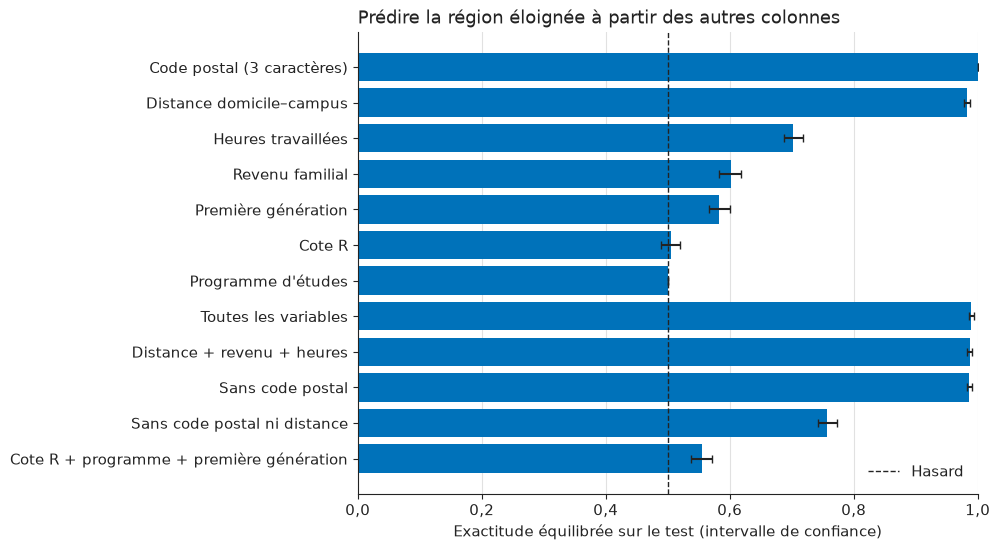

In [18]:
proxys_seuls = vue_proxy.loc[[LIBELLES[colonne] for colonne in VARIABLES_PROXY]].sort_values("BA test")
combinaisons = vue_proxy.loc[list(ENSEMBLES_PROXY)[len(VARIABLES_PROXY) :]].sort_values("BA test")
ordre_figure = pd.concat([combinaisons, proxys_seuls])
bornes_figure = np.vstack(resultats_proxy.loc[ordre_figure.index, "BA IC"].to_numpy())
marges = np.clip(
    [ordre_figure["BA test"] - bornes_figure[:, 0], bornes_figure[:, 1] - ordre_figure["BA test"]], 0, None
)

figure, axe = plt.subplots(figsize=TAILLE_FIGURE_PROXYS)
axe.barh(
    ordre_figure.index,
    ordre_figure["BA test"],
    xerr=marges,
    color=BLEU_IVADO,
    error_kw={"ecolor": ENCRE, "capsize": TAILLE_EMBOUT},
)
axe.axvline(BA_HASARD, color=ENCRE, linestyle="--", linewidth=EPAISSEUR_REPERE, label="Hasard")
axe.set_xlim(0, 1)
axe.xaxis.set_major_formatter(FuncFormatter(lambda valeur, _: nombre(valeur, 1)))
styliser(
    axe,
    "Prédire la région éloignée à partir des autres colonnes",
    "Exactitude équilibrée sur le test (intervalle de confiance)",
    "",
    grille="x",
)
axe.legend(frameon=False, loc="lower right")
enregistrer(figure, "audit_proxys.png")

In [19]:
rang = proxys_seuls.sort_values("BA test", ascending=False)
sans_postal_distance = vue_proxy.loc["Sans code postal ni distance"]
dire(
    "**Classement des variables seules** (exactitude équilibrée sur le test) : "
    + " ; ".join(f"{nom} : {nombre(ligne['BA test'], 3)}" for nom, ligne in rang.iterrows())
    + f".\n\nLe code postal est la région elle-même ; la distance la prédit presque parfaitement "
    f"(AUC {nombre(vue_proxy.loc[LIBELLES[DISTANCE], 'AUC test'], 3)}) ; les heures travaillées et le revenu "
    "familial "
    "en portent une part nette. Sans code postal ni distance, les autres colonnes prédisent encore la "
    "région avec une "
    f"exactitude équilibrée de **{nombre(sans_postal_distance['BA test'], 3)}** "
    f"(AUC {nombre(sans_postal_distance['AUC test'], 3)}). Retirer l'étiquette ne retire pas le signal : un "
    "modèle "
    f"entraîné sur les décisions du comité retrouve la pénalité par ces chemins."
)

**Classement des variables seules** (exactitude équilibrée sur le test) : Code postal (3 caractères) : 1,000 ; Distance domicile–campus : 0,982 ; Heures travaillées : 0,702 ; Revenu familial : 0,602 ; Première génération : 0,583 ; Cote R : 0,505 ; Programme d'études : 0,500.

Le code postal est la région elle-même ; la distance la prédit presque parfaitement (AUC 0,997) ; les heures travaillées et le revenu familial en portent une part nette. Sans code postal ni distance, les autres colonnes prédisent encore la région avec une exactitude équilibrée de **0,758** (AUC 0,841). Retirer l'étiquette ne retire pas le signal : un modèle entraîné sur les décisions du comité retrouve la pénalité par ces chemins.

## 8. Métriques d'équité et justification

- **Parité démographique** : même taux d'octroi dans les deux groupes. Écart de parité = taux des grands centres − taux des régions éloignées.
- **Égalité des chances** (Hardt, Price et Srebro) : parmi les candidat·es qui méritent la bourse, même taux d'octroi dans les deux groupes. Écart = taux de vrais positifs (TVP) des grands centres − taux de vrais positifs des régions éloignées.

**Choix : l'égalité des chances.**

- Une bourse d'excellence promet la même chance aux candidat·es également méritant·es, quelle que soit leur région : c'est exactement ce que mesure l'égalité des chances.
- Les profils diffèrent entre groupes (cote R, revenu, heures, section 3) : la parité imposerait des taux égaux et écarterait des dossiers mieux classés au profit d'autres. Elle reste mesurée et rapportée.
- C'est aussi la métrique retenue par le correcteur du défi.

**Contre quoi la mesurer.** Pas contre `decision_octroi` : cette étiquette contient la pénalité (sections 4 et 5). Elle est mesurée contre des étalons de mérite plausibles, construits sans la région et sans les décisions du comité, sauf pour fixer des poids :

- (a) cote R seule ;
- (b) cote R et revenu familial, avec les poids de la règle du comité ;
- (c) cote R et heures travaillées, avec les poids de la règle du comité ;
- (d) test de résistance : cote R, revenu et heures standardisés, à poids égaux.

Chaque étalon retient les meilleurs dossiers au taux de référence du projet, avec le même départage déterministe. Le modèle en production est évalué contre chacun ; la bande min–max montre ce qui ne dépend pas de l'étalon choisi.

In [20]:
z_candidats = standardiser(candidats, CRITERES_NUMERIQUES)
poids_comite = coefficients_comite["Coefficient"]
scores_etalons = {
    "(a) Cote R seule": z_candidats[COTE_R],
    "(b) Cote R + revenu": poids_comite[COTE_R] * z_candidats[COTE_R]
    + poids_comite[REVENU] * z_candidats[REVENU],
    "(c) Cote R + heures": poids_comite[COTE_R] * z_candidats[COTE_R]
    + poids_comite[HEURES] * z_candidats[HEURES],
    "(d) Poids égaux": z_candidats.sum(axis=1),
}
etalons = {
    nom: selection_meilleurs(score.to_numpy(), TAUX_REFERENCE, candidats[IDENTIFIANT])
    for nom, score in scores_etalons.items()
}


def par_groupe(metrique, vrai, predit):
    return MetricFrame(
        metrics=metrique, y_true=vrai, y_pred=predit, sensitive_features=groupes_candidats
    ).by_group


def mesures_contre_etalon(decisions, etalon):
    tvp = par_groupe(true_positive_rate, etalon, decisions)
    taux_etalon = par_groupe(selection_rate, etalon, etalon)
    return {
        "Étalon, taux grands centres": taux_etalon[CENTRE],
        "Étalon, taux régions éloignées": taux_etalon[ELOIGNEE],
        "TVP grands centres": tvp[CENTRE],
        "TVP régions éloignées": tvp[ELOIGNEE],
        "Écart d'égalité des chances": tvp[CENTRE] - tvp[ELOIGNEE],
        "Concordance": accuracy_score(etalon, decisions),
    }


evaluation_production = pd.DataFrame(
    {nom: mesures_contre_etalon(decisions_production, etalon) for nom, etalon in etalons.items()}
).T
formats_taux = {
    colonne: pourcent for colonne in evaluation_production.columns if "taux" in colonne or "TVP" in colonne
}
afficher(
    evaluation_production.rename_axis("Modèle en production contre"), formats_taux | {"Concordance": pourcent}
)

ecarts_eo = evaluation_production["Écart d'égalité des chances"]
concordances = evaluation_production["Concordance"]
parite_etalons = (
    evaluation_production["Étalon, taux grands centres"]
    - evaluation_production["Étalon, taux régions éloignées"]
)
brief_dans_bande = ecarts_eo.min() <= ECART_EGALITE_CHANCES_BRIEF <= ecarts_eo.max()
ecart_tvp_comite = tvp_test[CENTRE] - tvp_test[ELOIGNEE]
etalon_du_brief = np.isclose(ecarts_eo.round(3), ECART_EGALITE_CHANCES_BRIEF)
verifier(
    {
        "l'étiquette du comité sous-estime l'écart": ecart_tvp_comite < ecarts_eo.min(),
        "aucun étalon ne reproduit l'écart du brief": not etalon_du_brief.any(),
    }
)
lecture_brief = (
    f"se situe dans cette bande sans correspondre à aucun des {nombre(len(etalons))} étalons : il ne "
    "permet pas d'identifier l'étalon caché"
    if brief_dans_bande
    else "sort de cette bande : l'étalon caché diffère de ceux-ci"
)
dire(
    f"Contre ces étalons, le modèle en production a un écart d'égalité des chances moyen de "
    f"**{nombre(ecarts_eo.mean(), 3)}** (de {nombre(ecarts_eo.min(), 3)} à {nombre(ecarts_eo.max(), 3)}) et "
    "une "
    f"concordance moyenne de {pourcent(concordances.mean())} (de {pourcent(concordances.min())} à "
    f"{pourcent(concordances.max())}). Son écart de parité sur les dossiers à évaluer est de "
    f"**{nombre(ecart_parite_eval, 3)}**. Le {nombre(ECART_EGALITE_CHANCES_BRIEF, 3)} annoncé par le brief "
    f"{lecture_brief}.\n\n"
    f"Contre decision_octroi, le même modèle n'affichait qu'un écart de taux de vrais positifs de "
    f"{nombre(ecart_tvp_comite, 3)} (section 5), sous le plus faible des écarts mesurés contre les étalons : "
    f"mesurer l'égalité des chances sur l'étiquette biaisée en masque l'essentiel.\n\n"
    "Aveugles à la région, les étalons ne donnent pas pour autant le même taux aux deux groupes : leur "
    "propre "
    f"écart de parité va de {nombre(parite_etalons.min(), 3)} à {nombre(parite_etalons.max(), 3)} selon le "
    "poids "
    "donné au revenu et aux heures. La parité n'est donc pas une conséquence du mérite ; l'imposer "
    "reviendrait à "
    f"départager selon la région plutôt que selon le dossier."
)

,"Étalon, taux grands centres","Étalon, taux régions éloignées",TVP grands centres,TVP régions éloignées,Écart d'égalité des chances,Concordance
Modèle en production contre,,,,,,
(a) Cote R seule,"42,9 %","35,8 %","99,7 %","76,8 %","0,229","94,1 %"
(b) Cote R + revenu,"44,9 %","32,9 %","97,3 %","83,7 %","0,135","95,2 %"
(c) Cote R + heures,"40,0 %","40,0 %","98,3 %","68,5 %","0,298","90,0 %"
(d) Poids égaux,"36,9 %","44,5 %","77,1 %","50,8 %","0,264","73,2 %"


Contre ces étalons, le modèle en production a un écart d'égalité des chances moyen de **0,231** (de 0,135 à 0,298) et une concordance moyenne de 88,1 % (de 73,2 % à 95,2 %). Son écart de parité sur les dossiers à évaluer est de **0,194**. Le 0,270 annoncé par le brief se situe dans cette bande sans correspondre à aucun des 4 étalons : il ne permet pas d'identifier l'étalon caché.

Contre decision_octroi, le même modèle n'affichait qu'un écart de taux de vrais positifs de 0,063 (section 5), sous le plus faible des écarts mesurés contre les étalons : mesurer l'égalité des chances sur l'étiquette biaisée en masque l'essentiel.

Aveugles à la région, les étalons ne donnent pas pour autant le même taux aux deux groupes : leur propre écart de parité va de −0,076 à 0,120 selon le poids donné au revenu et aux heures. La parité n'est donc pas une conséquence du mérite ; l'imposer reviendrait à départager selon la région plutôt que selon le dossier.

## 9. Constats de gouvernance

In [21]:
penalite = coefficients_comite.loc[INDICATRICE_ELOIGNEE]
revenu = coefficients_comite.loc[REVENU]
logit_par_point_cote_r = poids_comite[COTE_R] / ecarts_types[COTE_R]
profil_moyen = x_binaire.mean().to_frame().T
probabilites_profil = {
    groupe: modele_comite.predict_proba(profil_moyen.assign(**{INDICATRICE_ELOIGNEE: valeur}))[0, 1]
    for groupe, valeur in ((CENTRE, 0.0), (ELOIGNEE, 1.0))
}
x_sans_neutres = x_binaire.drop(columns=[*colonnes_programme, PREMIERE_GENERATION])
modele_sans_neutres = ajuster_logit(x_sans_neutres, y_demandes)
statistique_neutres, degres_neutres, p_neutres = rapport_vraisemblance(
    (modele_comite, x_binaire), (modele_sans_neutres, x_sans_neutres), y_demandes
)
coefficients_neutres = coefficients_comite.loc[[*colonnes_programme, PREMIERE_GENERATION], "Coefficient"]
capitale = coefficients_regions.loc["Capitale-Nationale"]
verifier(
    {
        "pénalité significative": penalite["IC haut"] < 0,
        "pénalité commune aux régions éloignées": p_regions > SEUIL_SIGNIFICATION,
        "Capitale-Nationale sans pénalité": capitale["IC bas"] < 0 < capitale["IC haut"],
        "effet positif du revenu significatif": revenu["IC bas"] > 0,
        "programme et première génération sans effet": p_neutres > SEUIL_SIGNIFICATION,
    }
)
dire(
    f"1. **Pénalité régionale, constat principal.** À dossier égal, résider en région éloignée retire "
    f"{nombre(-penalite['Coefficient'], 2)} sur l'échelle logit "
    f"(IC {intervalle_texte(penalite['IC bas'], penalite['IC haut'], 2)}), autant qu'une cote R plus faible "
    "de "
    f"{nombre(-penalite['Coefficient'] / logit_par_point_cote_r, 2)}. Pour un profil moyen, la probabilité "
    f"d'octroi passe de {pourcent(probabilites_profil[CENTRE])} en grand centre à "
    f"{pourcent(probabilites_profil[ELOIGNEE])} en région éloignée. La pénalité est statistiquement "
    f"indiscernable d'une région éloignée à l'autre (p = {nombre(p_regions, 3)}), absente en "
    f"Capitale-Nationale, et laisse {points(ecart_inexplique)} de l'écart sans "
    "explication. "
    f"Le modèle en production l'a apprise (écart de parité de {nombre(ecart_parite_test, 3)} au test, "
    f"{nombre(ecart_parite_eval, 3)} sur les dossiers à évaluer, écart d'égalité des chances de "
    f"{nombre(ecarts_eo.min(), 2)} à {nombre(ecarts_eo.max(), 2)}) et la retrouve par les proxys quand on "
    "retire "
    "la région.\n"
    f"2. **Revenu familial.** À dossier égal par ailleurs, un revenu familial plus élevé d'un écart-type "
    f"({nombre(ecarts_types[REVENU], 0)} $) pèse autant qu'une cote R plus forte de "
    f"{nombre(revenu['Coefficient'] / logit_par_point_cote_r, 2)} : un revenu plus élevé augmente la chance "
    "d'obtenir la bourse (signalé, non corrigé — hors du mandat régional).\n"
    f"3. **Première génération et programme.** Aucun effet détectable : coefficients entre "
    f"{nombre(coefficients_neutres.min(), 2)} et {nombre(coefficients_neutres.max(), 2)}, test conjoint du "
    "rapport "
    f"de vraisemblance p = {nombre(p_neutres, 2)}."
)

1. **Pénalité régionale, constat principal.** À dossier égal, résider en région éloignée retire 2,00 sur l'échelle logit (IC [−2,19 ; −1,81]), autant qu'une cote R plus faible de 1,45. Pour un profil moyen, la probabilité d'octroi passe de 40,5 % en grand centre à 8,5 % en région éloignée. La pénalité est statistiquement indiscernable d'une région éloignée à l'autre (p = 0,747), absente en Capitale-Nationale, et laisse 17,1 points de l'écart sans explication. Le modèle en production l'a apprise (écart de parité de 0,188 au test, 0,194 sur les dossiers à évaluer, écart d'égalité des chances de 0,14 à 0,30) et la retrouve par les proxys quand on retire la région.
2. **Revenu familial.** À dossier égal par ailleurs, un revenu familial plus élevé d'un écart-type (32 089 $) pèse autant qu'une cote R plus forte de 0,55 : un revenu plus élevé augmente la chance d'obtenir la bourse (signalé, non corrigé — hors du mandat régional).
3. **Première génération et programme.** Aucun effet détectable : coefficients entre −0,05 et 0,05, test conjoint du rapport de vraisemblance p = 0,96.

## 10. Export

Les chiffres de ce carnet sont exportés dans `output/audit.json`, arrondis, taux en fractions.

In [22]:
def arrondir(valeur):
    return round(float(valeur), DECIMALES_EXPORT)


def etendue(valeurs):
    return {
        "moyenne": arrondir(np.mean(valeurs)),
        "min": arrondir(np.min(valeurs)),
        "max": arrondir(np.max(valeurs)),
    }


def ligne_region(region):
    ligne = par_region.loc[region]
    return {
        "region": region,
        "groupe": ELOIGNEE if region in REGIONS_ELOIGNEES else CENTRE,
        "n": int(ligne["dossiers"]),
        "taux_octroi": arrondir(ligne["taux_octroi"]),
        "cote_r_moyenne": arrondir(ligne["cote_r_moyenne"]),
    }


def ligne_proxy(colonne):
    nom = LIBELLES[colonne]
    return {
        "variable": colonne,
        "auc_region": arrondir(vue_proxy.loc[nom, "AUC test"]),
        "ba_region": arrondir(vue_proxy.loc[nom, "BA test"]),
        "association": arrondir(associations.loc[nom, "Association"]),
        "mesure_association": associations.loc[nom, "Mesure"],
    }


coefficients_export = {CONSTANTE: modele_comite.intercept_[0]} | coefficients_comite["Coefficient"].to_dict()
audit = {
    "meta": {
        "date_execution": date.today().isoformat(),
        "n_historique": len(demandes),
        "n_evaluation": len(candidats),
        "taux_octroi_cible": TAUX_REFERENCE,
        "enveloppe": list(ENVELOPPE),
        "graine": GRAINE,
    },
    "diagnostic": {
        "taux_par_region": [ligne_region(region) for region in REGIONS],
        "ecart_octroi_centre_eloignee": arrondir(ecart_octroi),
        "part_expliquee_cote_r": arrondir(part_cote_r),
        "part_expliquee_autres_criteres": arrondir(part_autres_criteres),
        "part_inexpliquee": arrondir(part_inexpliquee),
        "penalite_regionale_logit": {
            region: arrondir(coefficients_regions.loc[region, "Coefficient"]) for region in REGIONS
        },
        "coefficients_comite": [
            {"variable": nom, "coef": arrondir(valeur)} for nom, valeur in coefficients_export.items()
        ],
        "proxys": sorted(
            (ligne_proxy(colonne) for colonne in VARIABLES_PROXY), key=lambda ligne: -ligne["auc_region"]
        ),
        "retrait_region": [
            {
                "essai": essai,
                "exactitude": arrondir(ligne["Exactitude"]),
                "ecart_parite": arrondir(ligne["Écart de parité"]),
            }
            for essai, ligne in retrait.iterrows()
        ],
    },
    "metriques": {
        "choix": "egalite_des_chances",
        "justification_courte": (
            "Bourse d'excellence : à mérite égal, même chance d'octroi quelle que soit la région. Les "
            "profils "
            "diffèrent entre groupes, la parité imposerait des taux égaux au détriment du mérite. Mesurée "
            "contre des "
            "étalons de mérite plausibles, jamais contre decision_octroi, qui contient la pénalité."
        ),
    },
    "modele_production": {
        "exactitude_test": arrondir(exactitude_test),
        "ecart_parite_test": arrondir(ecart_parite_test),
        "ecart_parite_eval": arrondir(ecart_parite_eval),
        "ecart_egalite_chances_ref": etendue(ecarts_eo),
        "concordance_ref": etendue(concordances),
        "taux_par_groupe": {groupe: arrondir(taux_production[groupe]) for groupe in (CENTRE, ELOIGNEE)},
    },
}
FICHIER_AUDIT.parent.mkdir(exist_ok=True)
FICHIER_AUDIT.write_text(json.dumps(audit, ensure_ascii=False, indent=2), encoding="utf-8")
dire(
    f"`{FICHIER_AUDIT.as_posix()}` écrit ; figures : "
    + ", ".join(f"`{chemin.as_posix()}`" for chemin in sorted(DOSSIER_FIGURES.glob("audit_*.png")))
    + "."
)

`output/audit.json` écrit ; figures : `figures/audit_proxys.png`, `figures/audit_taux_par_cote_r.png`.

## 11. Références

- IVADO, Hackathon Génie et Informatique 2026, défi ÉquiAlgo : carnet de départ `baseline_model.ipynb` et données synthétiques fournies.
- Hardt, M., Price, E. et Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. Advances in Neural Information Processing Systems (NeurIPS).
- Bird, S., Dudík, M., Edgar, R., Horn, B., Lutz, R., Milan, V., Sameki, M., Wallach, H. et Walker, K. (2020). *Fairlearn*. Microsoft, rapport technique MSR-TR-2020-32.
- Barocas, S., Hardt, M. et Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press, fairmlbook.org.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.
- Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. Nature Methods, 17, 261–272.

Outils d'IA utilisés : Claude (Anthropic) et OpenAI Codex, comme aide à l'écriture et à la vérification du code.